In [2]:
import pandas as pd
import numpy as np
import xarray as xr
import glob
import yaml
import os
import matplotlib.pyplot as plt
import pypsa

path = '/Users/mick/Documents/GitHub/masterthesis-mick/Wetterdaten'

In [2]:
## turbine in use: Vestas_V112_3MW

name = 'Vestas_V112_3MW'

with open(str(path + '/resources/' + name +'.yaml')) as f:
        config = yaml.safe_load(f)

POW, V, P, HUB_HEIGHT = (
        config["POW"],
        config["V"],
        config["P"],
        config["HUB_HEIGHT"]
    )

#HUB_HEIGHT = 100
# convert to np.array
POW = np.array(POW)
V = np.array(V)



In [20]:
def average_lat_long(ds, to_height=HUB_HEIGHT, from_height = 10, wnd_shear_exp=0.143):

    subset = ds.sel(
        latitude=slice(55.0, 49.0), 
        longitude=slice(6.0, 15.0)   
    )
    
    # calculate windspeed from u10 and v10 factors
    subset['windspeed'] = np.sqrt(subset["u10"]**2 + subset["v10"]**2)

    # use exponential power law to caclulate the wind_speed at the turbines height
    subset["windspeed"] = subset['windspeed'] * (to_height / from_height) ** wnd_shear_exp

    return subset['windspeed'].mean(dim=("latitude", "longitude"))

def get_capacity_facors(data: xr):
    # Funktion zum Umrechnen von Windgeschwindigkeit -> CF

    def apply_power_curve(da):
        return np.interp(da, V, POW / P)  # normierte Leistung (0–1)

    # Auf DataArray anwenden
    cf = xr.apply_ufunc(
        apply_power_curve,
        data,
        input_core_dims=[[]],
        output_core_dims=[[]],
        output_dtypes=[data.dtype],
        dask="parallelized",
    )

    # Optional: Name & Attribute setzen
    cf.name = "capacity_factor"

    return cf

def get_pypsa_export_structure(data: xr):

    cf = []

    for i in range(0, data.number[-1].values):
        index = pd.date_range(
            start="2019-01-01 00:00",
            # CHANGE END HERE
            end="2020-01-02 00:00",
            freq="3h"
        )

        df = pd.DataFrame(index=index)
        df[f'cf_onwind_{i+1}'] = np.NaN

        for data_chunk in data:
            dt = data_chunk['valid_time'].values
            dt_str = pd.to_datetime(dt).strftime("%Y-%m-%d %H:%M:%S")  
            df.loc[dt_str, f'cf_onwind_{i+1}'] = data_chunk[i].values

        df[f'cf_onwind_{i+1}'] = df[f'cf_onwind_{i+1}'].interpolate(method="linear")
        cf.append(df)

    return cf
    
    
def prepare_dataset_wind():

    liste = []

    for file_name in glob.glob("/Users/mick/Documents/GitHub/masterthesis-mick/Wetterdaten/ECWMF_Data/*.grb"):
        ds = xr.open_dataset(
                file_name,
                engine="cfgrib",
                backend_kwargs={
                    "filter_by_keys": {
                        "paramId": [165, 166],
                    }
                }
            )
        
        ds = average_lat_long(ds)
        ds.expand_dims(time=[str(ds['time'].values)[:10]])

        liste.append(ds)
        
    data = xr.concat(liste, dim='time')
    data = data.sortby("time")

    data = get_capacity_facors(data)
    
    data = get_pypsa_export_structure(data)

    return data

In [21]:
data = prepare_dataset_wind()

In [24]:
for i in range(0,50):
    data[i] = data[i].loc[:'2019-12-31 22:00']

In [25]:
list_onwind = []
for i in range(0,50):
    list_onwind.append((data[i].sum().max()))

print(np.mean(list_onwind))

709.464621597608


In [3]:
data = pd.read_pickle('/Users/mick/Documents/GitHub/masterthesis-mick/Wetterdaten/cappacity_factors_prepared/cf_onwind.pkl')

In [4]:
data[10].sum()

cf_onwind_11    711.80855
dtype: float64

In [5]:
n = pypsa.Network('/Users/mick/Documents/GitHub/masterthesis-mick/base_s_1__none_2035_lt.nc')

INFO:pypsa.io:Imported network base_s_1__none_2035_lt.nc has buses, carriers, generators, global_constraints, links, loads, storage_units, stores


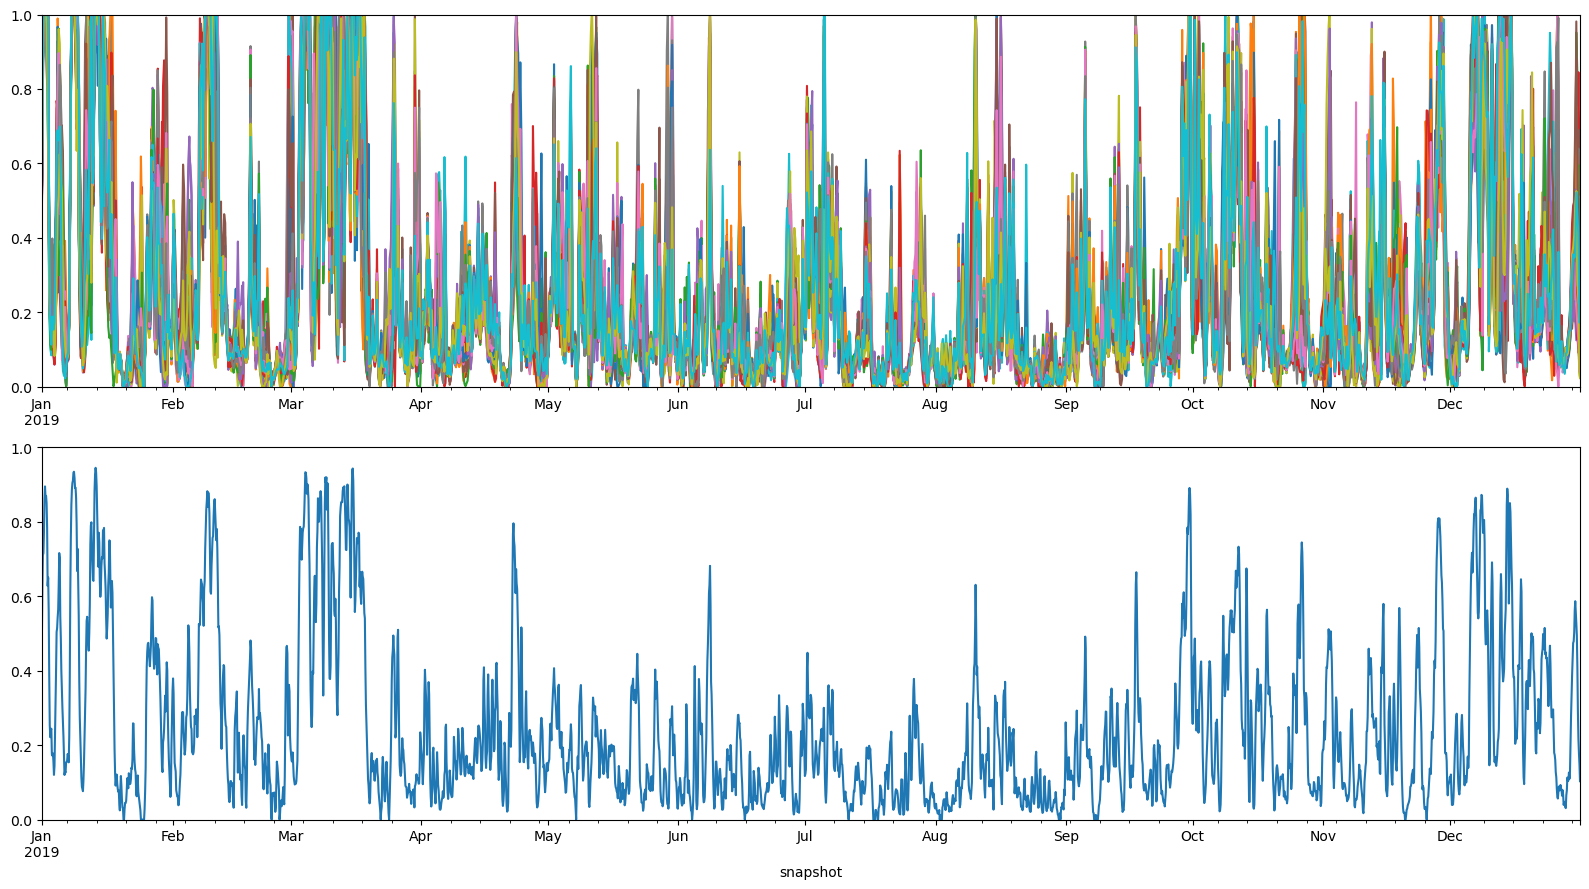

In [7]:
fig, ax = plt.subplots(2, 1, figsize=(16,9))

limit = "2019-12-31 22:00"

for i in range(0,50):
    data[i].plot(
        ax=ax[0],
        legend=False,
        ylim=(0,1)
    )

n.generators_t.p_max_pu['DE0 0 onwind-2035'].plot(
    ax=ax[1],
    label='real_cf',
    ylim=(0,1)
)

plt.tight_layout()
#ax[0].legend()


In [29]:
data[6][:12]

,cf_onwind_7
2019-01-01 00:00:00,0.186082
2019-01-01 03:00:00,0.264403
2019-01-01 06:00:00,0.342725
2019-01-01 09:00:00,0.479919
2019-01-01 12:00:00,0.617112
2019-01-01 15:00:00,0.645597
2019-01-01 18:00:00,0.674081
2019-01-01 21:00:00,0.651942
2019-01-02 00:00:00,0.629802
2019-01-02 03:00:00,0.571943


In [26]:
pd.to_pickle(data, "/Users/mick/Documents/GitHub/masterthesis-mick/Wetterdaten/cappacity_factors_prepared/cf_onwind.pkl")